# Method: Random Forest Wheat Segmentation

This method was inspired by the **EWS benchmark repository by Radek Zenkl and collaborators** https://github.com/RadekZenkl/EWS. It gave us a useful starting point for the overall idea of using a classical machine learning approach on the EWS wheat segmentation dataset. For our version, we built a simpler and more friendly baseline using handcrafted colour features and a **Random Forest** classifier to separate wheat from background. Tuning was built upon Chris Morris' baseline

## 1. Load and Prepare the Wheat Dataset

In [1]:
import os
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
# paths
PROJECT_ROOT = Path("../..").resolve()
DATA_DIR = PROJECT_ROOT / "EWS-Dataset"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "validation"
TEST_DIR = DATA_DIR / "test"

print("train exists     :", TRAIN_DIR.exists())
print("validation exists:", VAL_DIR.exists())                                                             
print("test exists      :", TEST_DIR.exists())

train exists     : True
validation exists: True
test exists      : True


## Helper functions

- load images and masks
- build the handcrafted features
- train the model
- make predictions
- calculate the final results


In [3]:
def get_image_paths(split_dir):
    split_dir = Path(split_dir)
    all_pngs = sorted(split_dir.glob("*.png"))
    image_paths = [p for p in all_pngs if not p.name.endswith("_mask.png")]
    return image_paths


def get_mask_path(image_path):
    image_path = Path(image_path)
    return image_path.with_name(image_path.stem + "_mask.png")


def load_rgb_image(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"could not load image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def load_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if mask is None:
        raise FileNotFoundError(f"could not load mask: {path}")
    mask = (mask > 127).astype(np.uint8)
    return mask


def rgb_to_hsi_features(rgb_img):
    rgb = rgb_img.astype(np.float32) / 255.0
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]

    intensity = (r + g + b) / 3.0
    min_rgb = np.minimum(np.minimum(r, g), b)

    saturation = np.zeros_like(intensity)
    valid = intensity > 1e-8
    saturation[valid] = 1.0 - (min_rgb[valid] / intensity[valid])

    num = 0.5 * ((r - g) + (r - b))
    den = np.sqrt((r - g) ** 2 + (r - b) * (g - b)) + 1e-8
    theta = np.arccos(np.clip(num / den, -1.0, 1.0))

    hue = np.where(b <= g, theta, 2 * np.pi - theta)
    hue = hue / (2 * np.pi)

    return hue, saturation, intensity


def compute_pixel_features(rgb_img):
    rgb = rgb_img.astype(np.float32) / 255.0
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]

    hsv = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2HSV).astype(np.float32)
    h_hsv = hsv[:, :, 0] / 179.0
    s_hsv = hsv[:, :, 1] / 255.0
    v_hsv = hsv[:, :, 2] / 255.0

    lab = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2LAB).astype(np.float32)
    l_lab = lab[:, :, 0] / 255.0
    a_lab = (lab[:, :, 1] - 128.0) / 127.0
    b_lab = (lab[:, :, 2] - 128.0) / 127.0

    ycrcb = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    y_ycc = ycrcb[:, :, 0] / 255.0
    cr_ycc = (ycrcb[:, :, 1] - 128.0) / 127.0
    cb_ycc = (ycrcb[:, :, 2] - 128.0) / 127.0

    h_hsi, s_hsi, i_hsi = rgb_to_hsi_features(rgb_img)

    exg = 2 * g - r - b
    ngrdi = (g - r) / (g + r + 1e-8)

    features = np.stack(
        [
            r, g, b,
            h_hsv, s_hsv, v_hsv,
            l_lab, a_lab, b_lab,
            y_ycc, cr_ycc, cb_ycc,
            h_hsi, s_hsi, i_hsi,
            exg, ngrdi,
        ],
        axis=-1,
    )

    h, w, c = features.shape
    return features.reshape(h * w, c)

## Check using 1 image

number of training images: 142
sample image: FPWW0220011_RGB1_20180316_100219_6.png
image shape : (350, 350, 3)
mask shape  : (350, 350)


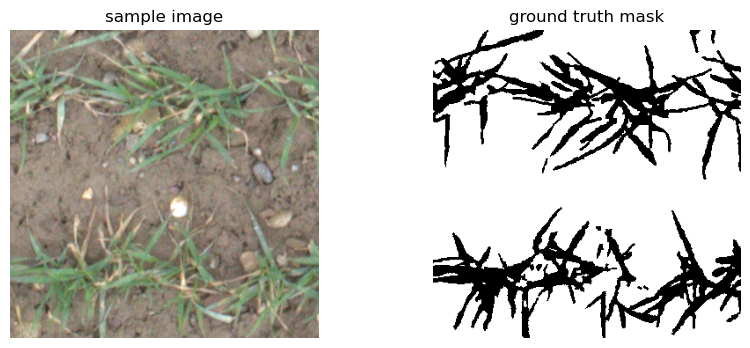

In [4]:
train_images = get_image_paths(TRAIN_DIR)
print("number of training images:", len(train_images))

sample_img_path = train_images[0]
sample_mask_path = get_mask_path(sample_img_path)

sample_img = load_rgb_image(sample_img_path)
sample_mask = load_mask(sample_mask_path)

print("sample image:", sample_img_path.name)
print("image shape :", sample_img.shape)
print("mask shape  :", sample_mask.shape)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(sample_img)
ax[0].set_title("sample image")
ax[0].axis("off")

ax[1].imshow(sample_mask, cmap="gray")
ax[1].set_title("ground truth mask")
ax[1].axis("off")
plt.show()

## 2. Build the Features for the Model

In [5]:
def build_training_set(split_dir, pixels_per_image=4000, max_images=None, random_state=42):
    rng = np.random.default_rng(random_state)
    image_paths = get_image_paths(split_dir)

    if max_images is not None:
        image_paths = image_paths[:max_images]

    X_list = []
    y_list = []

    for image_path in image_paths:
        mask_path = get_mask_path(image_path)

        img = load_rgb_image(image_path)
        mask = load_mask(mask_path)

        X_img = compute_pixel_features(img)
        y_img = mask.reshape(-1)

        n_pixels = len(y_img)
        sample_n = min(pixels_per_image, n_pixels)
        idx = rng.choice(n_pixels, size=sample_n, replace=False)

        X_list.append(X_img[idx])
        y_list.append(y_img[idx])

    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    return X, y


X_train, y_train = build_training_set(
    TRAIN_DIR,
    pixels_per_image=4000,   # safe starting point
    max_images=None,         # use all training images
    random_state=42
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("plant pixels:", int(y_train.sum()))
print("soil pixels :", int((y_train == 0).sum()))


X_train shape: (568000, 17)
y_train shape: (568000,)
plant pixels: 449006
soil pixels : 118994


## 3. Train the Random Forest Model

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

start_train = time.time()

rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=20,
    n_jobs=-1,
    random_state=42,
    class_weight="balanced_subsample"
)

rf.fit(X_train_scaled, y_train)

train_time = time.time() - start_train
print(f"training finished in {train_time:.2f} seconds")


training finished in 25.23 seconds


## Prediction and evaluation helpers

In [7]:
def predict_mask(model, scaler, rgb_img):
    X = compute_pixel_features(rgb_img)
    X_scaled = scaler.transform(X)
    pred = model.predict(X_scaled)
    return pred.reshape(rgb_img.shape[:2]).astype(np.uint8)


def evaluate_split(split_dir, model, scaler, max_images=None):
    image_paths = get_image_paths(split_dir)
    if max_images is not None:
        image_paths = image_paths[:max_images]

    image_metrics = []
    predictions = []
    ground_truths = []
    image_names = []

    start_test = time.time()

    for image_path in image_paths:
        mask_path = get_mask_path(image_path)

        img = load_rgb_image(image_path)
        gt = load_mask(mask_path)
        pred = predict_mask(model, scaler, img)

        precision = precision_score(gt.reshape(-1), pred.reshape(-1), zero_division=0)
        recall = recall_score(gt.reshape(-1), pred.reshape(-1), zero_division=0)
        f1 = f1_score(gt.reshape(-1), pred.reshape(-1), zero_division=0)
        iou = jaccard_score(gt.reshape(-1), pred.reshape(-1), zero_division=0)

        image_metrics.append([precision, recall, f1, iou])
        predictions.append(pred)
        ground_truths.append(gt)
        image_names.append(image_path.name)

    test_time = time.time() - start_test

    image_metrics = np.array(image_metrics)
    summary = {
        "precision": float(image_metrics[:, 0].mean()),
        "recall": float(image_metrics[:, 1].mean()),
        "f1": float(image_metrics[:, 2].mean()),
        "iou": float(image_metrics[:, 3].mean()),
        "time_seconds": float(test_time),
        "num_images": len(image_paths),
    }

    return summary, image_names, predictions, ground_truths


## Validate on the validation split

Tune on validation first. Save the test split for final evaluation.

In [8]:
val_summary, val_names, val_preds, val_gts = evaluate_split(VAL_DIR, rf, scaler)

print("validation summary")
for k, v in val_summary.items():
    print(f"{k:>12}: {v:.4f}" if isinstance(v, float) else f"{k:>12}: {v}")


validation summary
   precision: 0.9260
      recall: 0.8869
          f1: 0.9024
         iou: 0.8313
time_seconds: 6.5893
  num_images: 24


## Final evaluation on the test split

In [9]:
test_summary, test_names, test_preds, test_gts = evaluate_split(TEST_DIR, rf, scaler)

print("test summary")
for k, v in test_summary.items():
    print(f"{k:>12}: {v:.4f}" if isinstance(v, float) else f"{k:>12}: {v}")


test summary
   precision: 0.9211
      recall: 0.8907
          f1: 0.9019
         iou: 0.8272
time_seconds: 6.2479
  num_images: 24


## Visualise some results

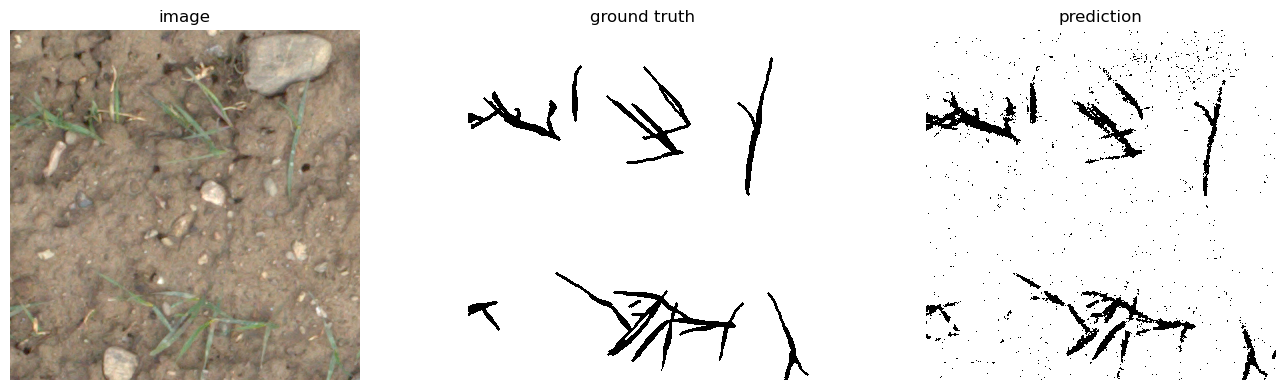

In [10]:
def show_result(split_names, preds, gts, split_dir, idx=0):
    image_path = Path(split_dir) / split_names[idx]
    img = load_rgb_image(image_path)

    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    ax[0].imshow(img)
    ax[0].set_title("image")
    ax[0].axis("off")

    ax[1].imshow(gts[idx], cmap="gray")
    ax[1].set_title("ground truth")
    ax[1].axis("off")

    ax[2].imshow(preds[idx], cmap="gray")
    ax[2].set_title("prediction")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()


show_result(test_names, test_preds, test_gts, TEST_DIR, idx=0)
